In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# split_train.parquet, split_val.parquet, split_test.parquet
uploaded = files.upload()

df_train = pd.read_parquet("split_train.parquet")
df_val   = pd.read_parquet("split_val.parquet")
df_test  = pd.read_parquet("split_test.parquet")

KEYWORDS   = df_train["keyword"].unique()
CITIES     = df_train["city"].unique()
SEQ_LEN    = 6   # look back 6 months
HORIZONS   = [1, 2, 3]

print(f"Train: {len(df_train)} rows")
print(f"Val:   {len(df_val)} rows")
print(f"Test:  {len(df_test)} rows")
print(f"Keywords: {list(KEYWORDS)}")
print(f"Cities:   {list(CITIES)}")

Saving split_test.parquet to split_test.parquet
Saving split_val.parquet to split_val.parquet
Saving split_train.parquet to split_train.parquet
Train: 5112 rows
Val:   216 rows
Test:  1116 rows
Keywords: ['birria', 'birria tacos', 'boba', 'charcuterie', 'elote', 'korean fried chicken', 'matcha', 'shakshuka', 'smash burger', 'truffle fries', 'tteokbokki', 'wagyu']
Cities:   ['Nashville', 'Philadelphia', 'Tampa']


In [ ]:
!pip install torch --quiet

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
def build_sequences(df, seq_len, horizons):
    X_all, y_all, meta = [], [], []

    for city in df["city"].unique():
        for kw in df["keyword"].unique():
            series = (
                df[(df["city"] == city) & (df["keyword"] == kw)]
                .sort_values("month")
                .reset_index(drop=True)
            )
            values = series["trend_score_smooth"].values
            months = series["month"].values

            for i in range(seq_len, len(values)):
                x_seq = values[i - seq_len:i]
                for h in horizons:
                    target_idx = i + h - 1
                    if target_idx >= len(values):
                        continue
                    X_all.append(x_seq)
                    y_all.append(values[target_idx])
                    meta.append({
                        "city": city,
                        "keyword": kw,
                        "horizon": h,
                        "month": months[target_idx]
                    })

    return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32), meta

# Combine train+val into one training pool
df_trainval = pd.concat([df_train, df_val]).sort_values("month")

# Use last 20% of trainval as internal validation
all_months  = sorted(df_trainval["month"].unique())
split_idx   = int(len(all_months) * 0.8)
val_cutoff  = all_months[split_idx]

df_tr  = df_trainval[df_trainval["month"] <= val_cutoff]
df_vl  = df_trainval[df_trainval["month"] > val_cutoff]

X_train, y_train, meta_train = build_sequences(df_tr,   SEQ_LEN, HORIZONS)
X_val,   y_val,   meta_val   = build_sequences(df_vl,   SEQ_LEN, HORIZONS)
X_test,  y_test,  meta_test  = build_sequences(df_test, SEQ_LEN, HORIZONS)

print(f"Train sequences: {X_train.shape}")
print(f"Val sequences:   {X_val.shape}")
print(f"Test sequences:  {X_test.shape}")

Train sequences: (12096, 6)
Val sequences:   (2376, 6)
Test sequences:  (2592, 6)


In [ ]:
class TrendLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, 1)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # take last timestep
        return out.squeeze(-1)

model = TrendLSTM(input_size=1, hidden_size=128, num_layers=2, dropout=0.2).to(device)
print(model)

TrendLSTM(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [16]:
# Reshape X for LSTM: (batch, seq_len, features)
X_train_t = torch.tensor(X_train).unsqueeze(-1).to(device)
y_train_t = torch.tensor(y_train).to(device)
X_val_t   = torch.tensor(X_val).unsqueeze(-1).to(device)
y_val_t   = torch.tensor(y_val).to(device)

dataset    = torch.utils.data.TensorDataset(X_train_t, y_train_t)
loader     = DataLoader(dataset, batch_size=64, shuffle=True)

optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion  = nn.MSELoss()

EPOCHS = 100
best_val_loss = float("inf")
best_model_state = None

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(X_train)

    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} --> Train Loss: {train_loss:.8f}, Val Loss: {val_loss:.8f}")

# Restore best model
model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.8f}")

Epoch 10/100 --> Train Loss: 0.00000068, Val Loss: 0.00000024
Epoch 20/100 --> Train Loss: 0.00000065, Val Loss: 0.00000041
Epoch 30/100 --> Train Loss: 0.00000065, Val Loss: 0.00000030
Epoch 40/100 --> Train Loss: 0.00000065, Val Loss: 0.00000028
Epoch 50/100 --> Train Loss: 0.00000064, Val Loss: 0.00000036
Epoch 60/100 --> Train Loss: 0.00000064, Val Loss: 0.00000030
Epoch 70/100 --> Train Loss: 0.00000063, Val Loss: 0.00000021
Epoch 80/100 --> Train Loss: 0.00000062, Val Loss: 0.00000031
Epoch 90/100 --> Train Loss: 0.00000061, Val Loss: 0.00000043
Epoch 100/100 --> Train Loss: 0.00000062, Val Loss: 0.00000027

Best val loss: 0.00000020


In [ ]:
from sklearn.metrics import mean_absolute_error

model.eval()
X_test_t = torch.tensor(X_test).unsqueeze(-1).to(device)

with torch.no_grad():
    y_pred = model(X_test_t).cpu().numpy()

# Build results dataframe
results_df = pd.DataFrame(meta_test)
results_df["actual"]    = y_test
results_df["predicted"] = y_pred
results_df["abs_error"] = np.abs(y_test - y_pred)

# MAE by horizon
mae_by_horizon = (
    results_df.groupby("horizon")["abs_error"]
    .mean()
    .reset_index()
    .rename(columns={"abs_error": "MAE"})
)
print("LSTM MAE by Forecast Horizon:")
print(mae_by_horizon.to_string(index=False))

# MAE by keyword
mae_by_keyword = (
    results_df.groupby(["keyword", "horizon"])["abs_error"]
    .mean()
    .unstack(level="horizon")
    .round(6)
)
print("\nMAE by keyword (columns = horizon):")
print(mae_by_keyword)

LSTM MAE by Forecast Horizon:
 horizon      MAE
       1 0.000482
       2 0.000561
       3 0.000649

MAE by keyword (columns = horizon):
horizon                      1         2         3
keyword                                           
birria                0.000942  0.001136  0.001352
birria tacos          0.000595  0.000725  0.000878
boba                  0.001068  0.001156  0.001326
charcuterie           0.000548  0.000616  0.000703
elote                 0.000251  0.000279  0.000320
korean fried chicken  0.000300  0.000367  0.000424
matcha                0.000468  0.000622  0.000713
shakshuka             0.000224  0.000263  0.000308
smash burger          0.000174  0.000208  0.000245
truffle fries         0.000375  0.000454  0.000540
tteokbokki            0.000176  0.000195  0.000210
wagyu                 0.000665  0.000709  0.000766


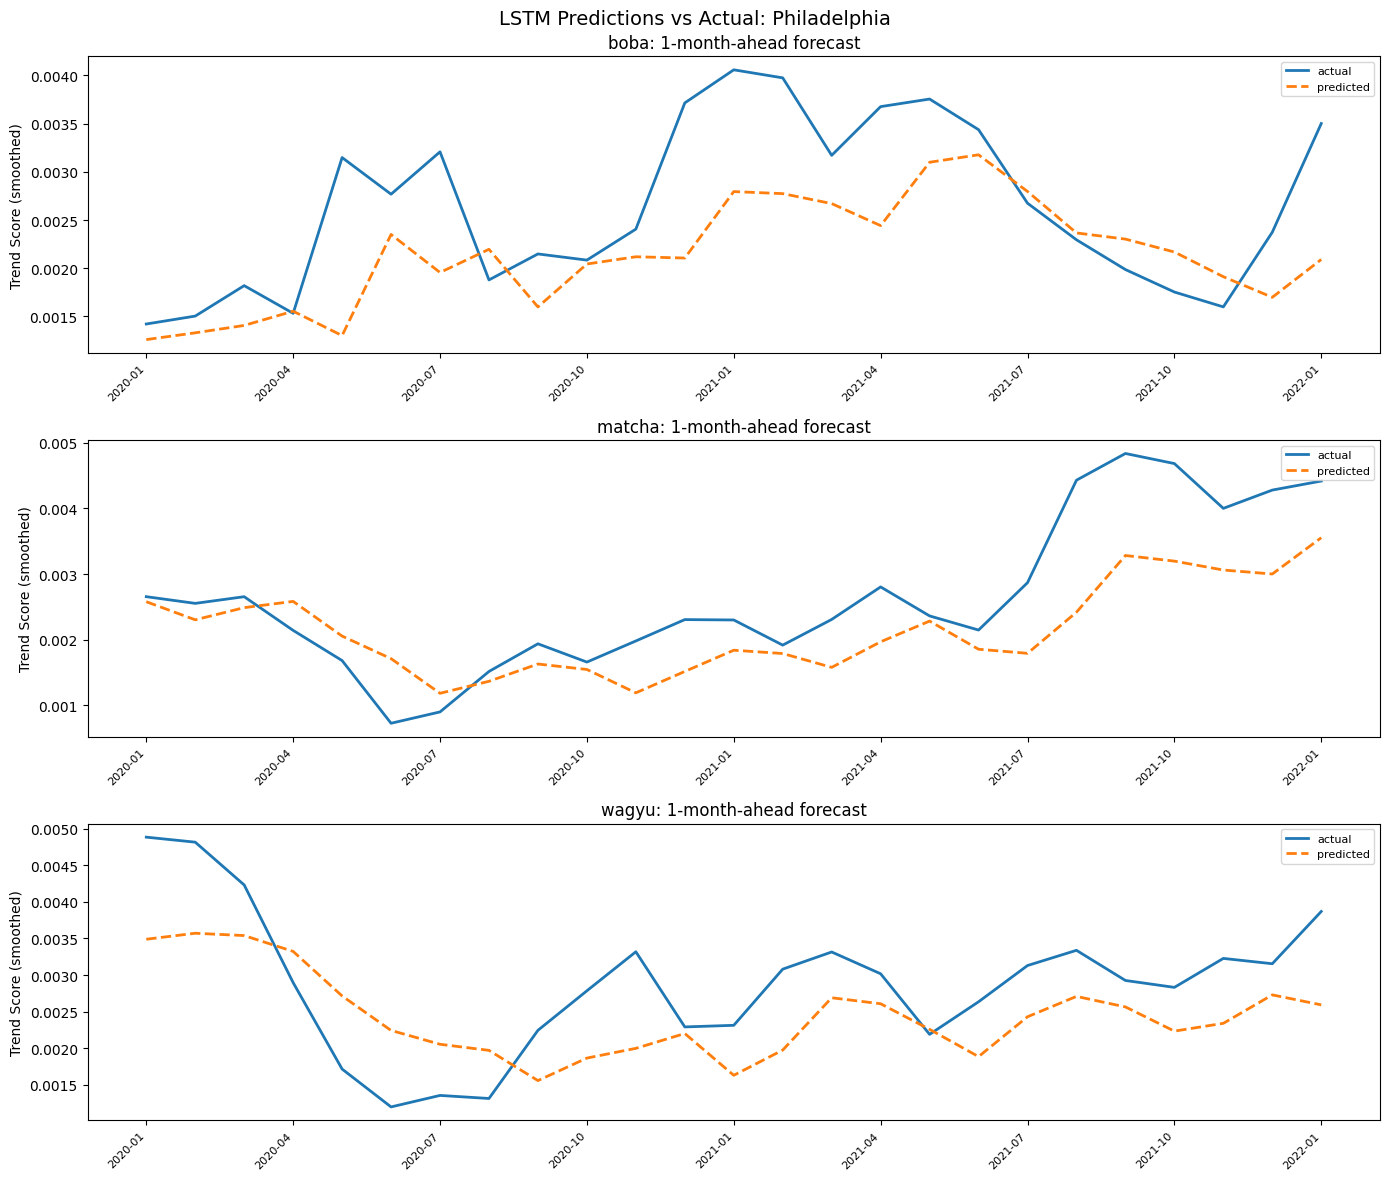

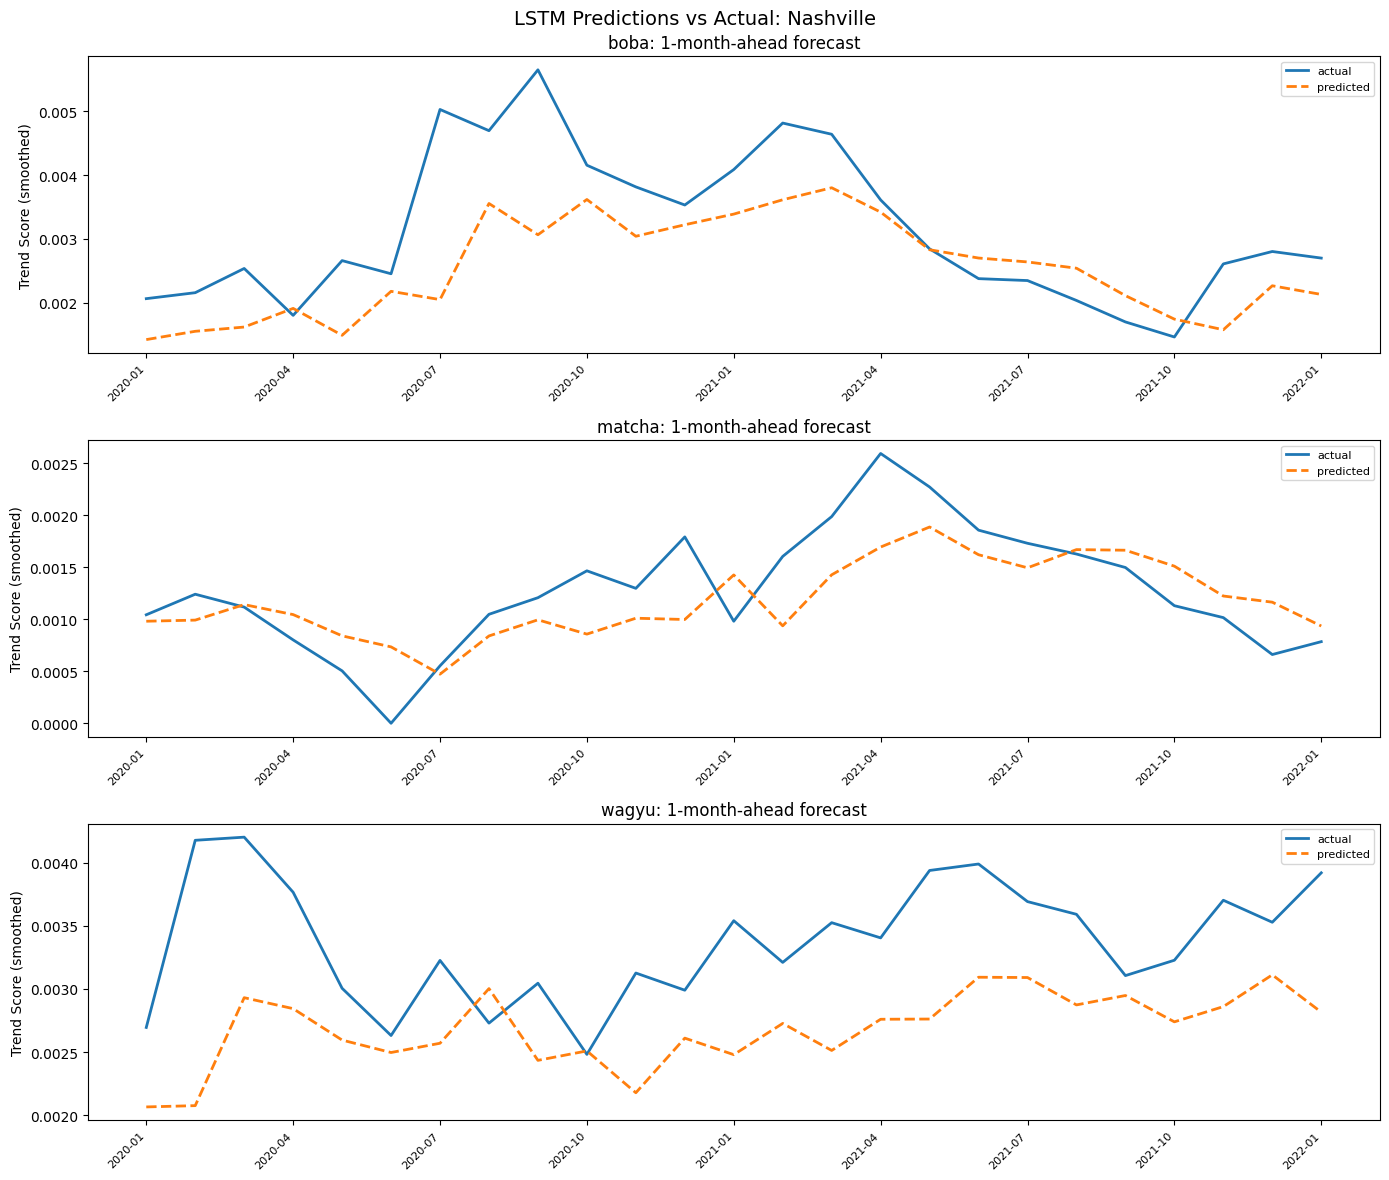

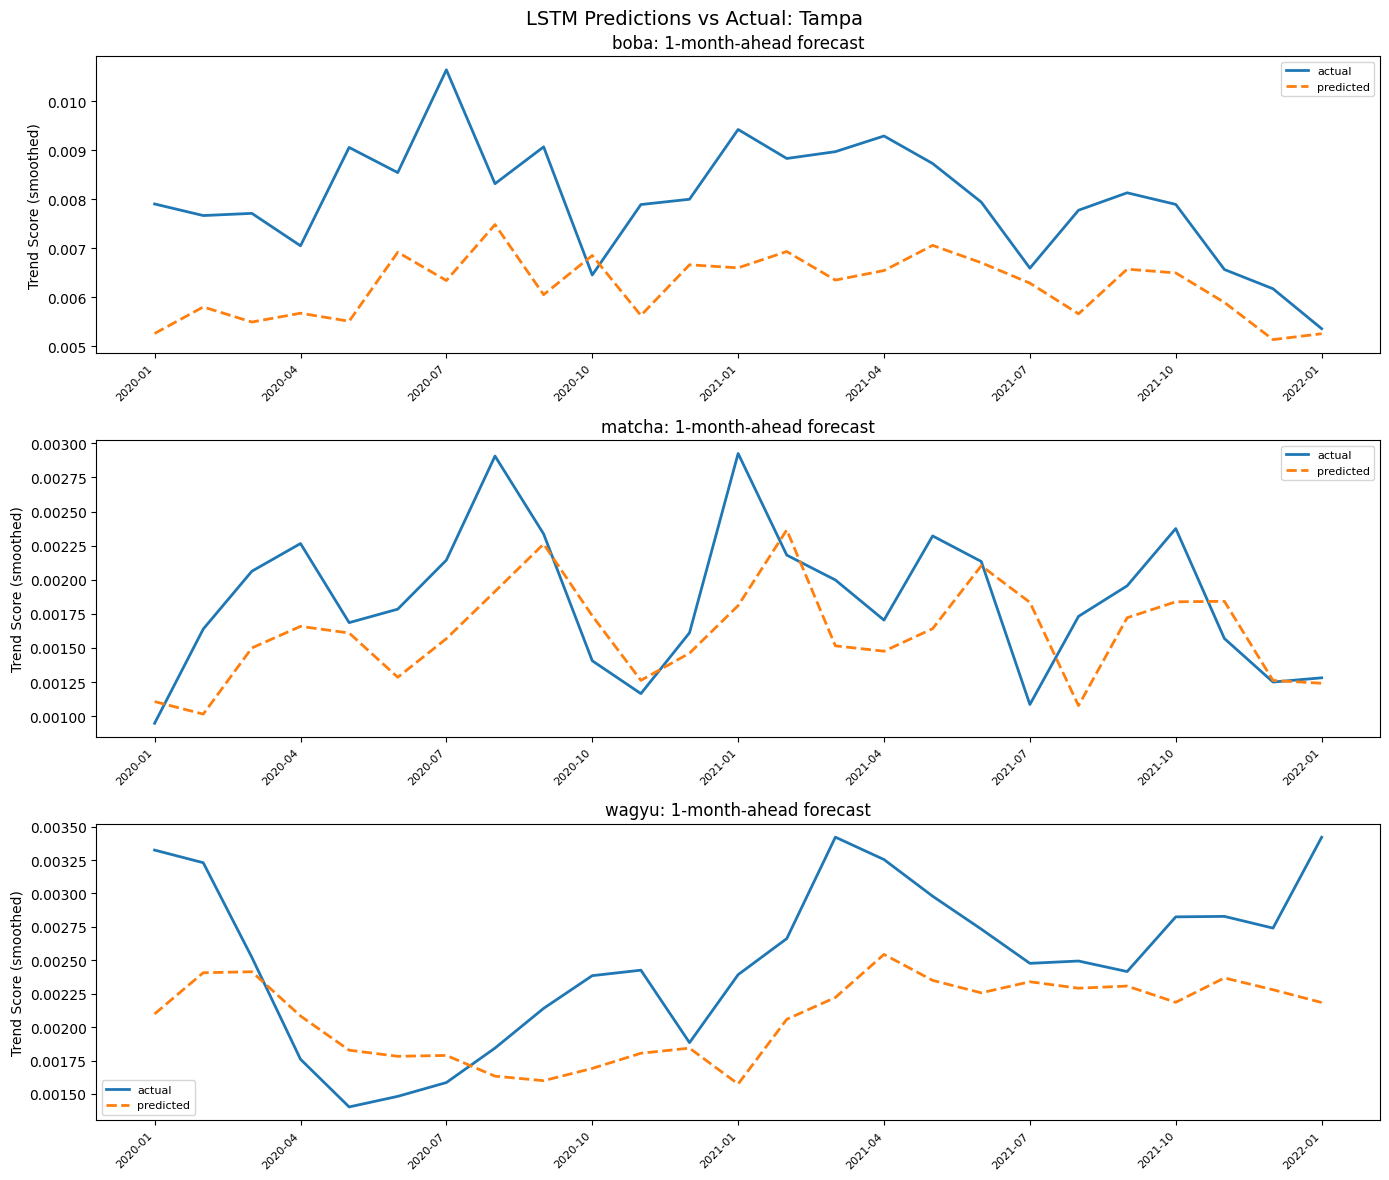

In [17]:
import matplotlib.pyplot as plt

keywords_to_plot = ["boba", "matcha", "wagyu"]
cities_to_plot = ["Philadelphia", "Nashville", "Tampa"]

for city_to_plot in cities_to_plot:
    fig, axes = plt.subplots(len(keywords_to_plot), 1, figsize=(14, 12), sharex=False)

    for ax, kw in zip(axes, keywords_to_plot):
        subset = results_df[
            (results_df["city"] == city_to_plot) &
            (results_df["keyword"] == kw) &
            (results_df["horizon"] == 1)
        ].sort_values("month").reset_index(drop=True)

        if subset.empty:
            ax.set_title(f"{kw} (no predictions)")
            continue

        ax.plot(range(len(subset)), subset["actual"], label="actual", linewidth=2)
        ax.plot(range(len(subset)), subset["predicted"], label="predicted", linewidth=2, linestyle="--")

        ax.set_title(f"{kw}: 1-month-ahead forecast")
        ax.set_ylabel("Trend Score (smoothed)")
        ax.legend(fontsize=8)

        n = len(subset)
        step = max(n // 8, 1)
        tick_positions = list(range(0, n, step))
        tick_labels = [subset["month"].iloc[i] for i in tick_positions]

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)

    plt.suptitle(f"LSTM Predictions vs Actual: {city_to_plot}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [18]:
save_cols = ["city", "month", "keyword", "horizon", "actual", "predicted", "abs_error"]
results_df[save_cols].to_parquet("lstm_predictions.parquet", index=False)
files.download("lstm_predictions.parquet")
print("Downloaded lstm_predictions.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded lstm_predictions.parquet
